# TODO:
- review Oja's rule

# Introduction

## Intialization

## Run This First

Run the next code cell before the rest of the notebook.

- In Google Colab it installs any missing notebook-only packages and enables widget support.
- In local JupyterLab it only verifies imports against your active environment.
- Local setup: create a virtual environment and install the packages in `requirements-notebooks.txt`.


In [ ]:
# Notebook runtime setup for Google Colab and local JupyterLab.
import importlib
import subprocess
import sys

try:
    from google.colab import output as colab_output
    IS_COLAB = True
except ImportError:
    colab_output = None
    IS_COLAB = False


def ensure_notebook_packages(requirements):
    if not IS_COLAB:
        return

    missing = []
    for package_name, module_name in requirements:
        if importlib.util.find_spec(module_name) is None:
            missing.append(package_name)

    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])


NOTEBOOK_REQUIREMENTS = [('ipywidgets', 'ipywidgets'), ('imageio', 'imageio'), ('matplotlib', 'matplotlib'), ('networkx', 'networkx'), ('numpy', 'numpy'), ('scipy', 'scipy')]
ensure_notebook_packages(NOTEBOOK_REQUIREMENTS)

if IS_COLAB:
    colab_output.enable_custom_widget_manager()


In [ ]:
# import dependencies
import os
import numpy as np
import matplotlib.pyplot as plt
import imageio
from scipy.special import expit # fast sigmoid computation
import networkx as nx
import itertools
from ipywidgets import interact
from IPython.display import display
from random import randint


Chemical and electrical signals are passed from neuron to neuron through synapses. Through these signals, a neuron can affect the activity of another neuron. Hebb noticed this and postulated that when a neuron excites or takes part repeatedly in firing another neuron, there is potentiation. This is called the "Hebb synapse". In other words, when a neuron increases the firing of another neuron, there is potentiation of the synapse. The inverse is true for depression of the synapse. Depression is necessary to prevent synapses from saturating to their maximal values.

In this project, we will see how self-organisation emerges from network plasticity via Hebbian rules. Our network will learn about a very simple combination of horizontal and vertical lines. With Hebb's rule as a basis, the network will learn without an explicit error signal from the environment, that is, without *supervision*.  As we train our network on these input patterns self-organization will happen in weight space, after which the network learns the statistical regularities in the input. 

For this project we will zoom out from biological complexity to understand the operating principles and we will assume that a *real number* represents the synaptic strength between a pre and a postsynaptic neuron. We will also regard the activity of neurons themselves as real numbers (possibly representing firing rate of a given neuronal population). Another simplification is that we will be dealing with 'discrete dynamics', that is, our network will be updated in discrete time steps. You may spot other simplifications as we go along. As stark as they may be, none is too tragic, and the main plasticity phenomena due to Hebbian rule is known to be robust when the biological complexity is re-introduced into the picture.

What does the network learn and how can we observe the process? Read on!


# Pre-requisites
- How to compute the propagation of activity in a neural network

# Learning goals

By going through this project, students learn:

- How to compute an activity dependent plasticity rule
- How Hebbian plasticity rule extracts regularities from inputs
- How to systematically create input patterns 
- How to train a network by presenting stimuli
- How to inspect and interpret network weights
- How to balance the weight change.

# Simple Hebbian Plasticity

In its simplest version, a change in the synaptic weight $w$ represents potentiation or depression. If the change in weight ($\Delta w$) is positive there is potentiation and negative represents depression. This change of weight is directly proportional to the activity of the pre-synaptic and the post-synaptic neuron. In the formula below we can see that $\Delta w$ is highest when both the pre- and post-synaptic neurons are co-activated.

------

$$
\Delta w_{ij}(t) = x_i(t) y_j(t)
$$

Such that the new weights would be 
$$
w_{ij}(t+1) = w_{ij}(t) + \Delta w_{ij}(t) 
$$
or, for the ones that prefer vector notation
$$
\Delta \mathbf{w}(t) = \mathbf{x}(t)\mathbf{y}(t)\\
\mathbf{w}(t+1) = \mathbf{w}(t) + \Delta \mathbf{w}(t)
$$

------

where $\Delta w_i$ is the change in synaptic weight $w_{i}$ as a function of the presynaptic neuron $i$, the presynaptic neuron's activity $x_i$ (i.e. the firing rate) and the postsynpatic neuron's activity $y_j$. We can visualize a simple network as seen in the following figure:


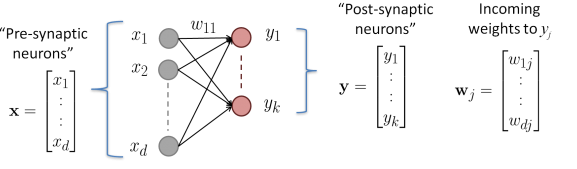



With this extremely simple learning rule, interesting things happen. We can think of a simple demonstration of how Hebbian learning leads the network to "discover" correlations in the input patterns it receives. Depicted in the diagram above is the input vector $\mathbf{x}$, the output vector $\mathbf{y}$, and the weight vector $\mathbf{w}$. As you know, $y$ is a linear combination (sum) of the inputs multiplied by the weights (the dot product). That is, 
$$
\mathbf{y} = \mathbf{x} \cdot \mathbf{w}
$$

For postsynaptic neuron $y_j$, we sum all the presynaptic neurons that have a synapse with $y_j$. For example, 

$$
y_1(t=0) = 
\begin{bmatrix}
    x_1(0) \\
    x_2(0) \\
    x_3(0) 
\end{bmatrix}\cdot 
\begin{bmatrix}
    w_{11}(0) \\
    w_{12}(0) \\
    w_{13}(0) 
\end{bmatrix}
=
\begin{bmatrix}
    1 \\
    -1 \\
    1 
\end{bmatrix}\cdot 
\begin{bmatrix}
    0.1 \\
    0.1 \\
    0.1
\end{bmatrix}
= (1\times0.1)+(-1\times0.1)+(1\times0.1) = 0.1
$$

Using the input vector ($\mathbf{x}$) and the output scalar ($y$), the new weight matrix $\mathbf{w}(t+1)$ can then be calculated in two steps:
$$
\Delta \mathbf{w}(t) = \mathbf{x}(t)y_j(t) \\
\mathbf{w}(t+1) = \mathbf{w}(t) + \Delta \mathbf{w}(t)
$$
Take note of what are the input correlations (statistical regularity) in this example. The activities of `x[0]` and `x[2]` co-occur, but the activity of `x[1]` does not. 

That is why, even though all the weights start out as $0.1$, the two correlated inputs dominate the receiving unit activation and their weights will continue to increase upon repeated presentation of the stimulus. The third unit sometimes goes up and sometimes down, with no net increase over time. Thus, Hebbian learning discovers correlations in the inputs.

------

> **Exercise 1**: Calculate the weight vector $\mathbf{w}$ at $t=2$ with pen and paper. 













## 1. Creat input patterns (training set)

Before we train our network, we have to decide on the inputs it will receive, that is, what are the 'patterns' or 'statistical regularities', present in the environment.

The world of our network will consist of vertial and horizontal lines. We start with creating a set of such **input patterns**, defined below.

---

> **Exercise 2**: Create $k$ input patterns, that is, $5 \times 5$ matrices. 
These patterns will serve as our **training set**. The input patterns in the training set must represent all unique combinations of two straight lines which can be vertical and horizontal. We will use combinatorics to produce all possible arrangements of two straight lines in this input space.

> **a.** How many ways are there to take 2 numbers from 10 numbers without replacement? Assume that the order does not matter. In combinatorics, this is called a **combination** and you can use `itertools.combinations(iterable,r)` to produce all the possible combinations of two numbers.

> **b.** Taking the numbers [1-5] as representing horizontal lines and [6-10] for the vertical lines, fill in matrices representing stimuli.

---




In [ ]:
# obtain all possible combinations of two numbers between 1-10:
nums = range(0,10) # 10 numbers 
combis = list(itertools.combinations(nums,2)) # 45 combinations

# Create a 5x5 empty Matrix
M = np.zeros((5,5))

# Fill in the sensory stimuli by indexing the appropriate row or column in the input matrix.
# fill in your stimuli in a 3D array called 'patterns'
patterns = []

for i,j in combis:
  B = np.copy(M)
  # fill each index (row or column) with ones
  if i <= 4:
    B[i,:] = 1 # fill that row with ones
  else:
    i = i - 5
    B[:,i] = 1 # fill that column with ones
  if j <= 4:
    B[j,:] = 1 # fill that row with ones
  else:
    j = j - 5
    B[:,j] = 1 # fill that column with ones
  patterns.append(B) 

# uncommment this to print all of the patterns
# for idx, p in enumerate(patterns):
#   print(f'-- {idx} --')
#   print(p)


# use this code to inspect *SOME* of the patterns you created
plt.figure(figsize=(10,5))
print('   Example patterns from training set')
plt.subplot(1,4,1), plt.spy(patterns[0],cmap='gist_gray');
plt.subplot(1,4,2), plt.spy(patterns[10],cmap='gist_gray');
plt.subplot(1,4,3), plt.spy(patterns[25],cmap='gist_gray');
plt.subplot(1,4,4), plt.spy(patterns[34],cmap='gist_gray');


In order to use the input patterns to train the network we need to vectorise them. 

> **Exercise 3:** vectorise / flatten the input patterns.

In [ ]:
# convert input matrices to vectors
X = [patterns[i].flatten() for i in range(len(patterns))]


## 2. Simple Hebbian Learning Algorithm
We will feed our input patterns one by one to our network. For every pattern we present to the network, we will compute the output activity and from there the change of weigths as a function of the output of the matrix. 

The steps are as follows:

**1.** Intialize our network as an adjacency matrix $\mathbf{W}$ with random weights. 

**2.** Compute the neuron output at iteration $t$ (where $t$ is the same as the pattern in the training sequence)

$$
\mathbf{y}(t) = \mathbf{x}(t)\mathbf{W}(t)
$$

where $\mathbf{x}(t)$ is the input vector presented at time step $t$, $\mathbf{W}(t)$ the weight matrix at time step $t$.

**3.** Calculate $\Delta \mathbf{W}(t)$

$$
\Delta \mathbf{W}(t) = \eta \mathbf{y}(t) \otimes \mathbf{x}(t)
$$

<!-- $$
\Delta \mathbf{W}(t) = \phi \mathbf{y}(t)[\frac{\gamma}{\phi}\mathbf{x}(t)]
$$ -->

<!-- - $\phi$ is the forgetting rate -->
With $\eta$, the learning rate, and the correlation between input and output is computed by the outer product between x and y.

**4.** Update the weight matrix $\mathbf{W}(t)$

$$
\mathbf{W}(t+1) = \mathbf{W}(t) + \Delta \mathbf{W}(t)
$$

**5.** Update `t` $\leftarrow$ `t+1`

**6.** Iterate, update: `t+1`, repeat this process from `step 2`.

This is done until (1) the training set has been completely presented, or (2) until the weights reach their steady state values, or (3) the experimenter decides to end training.


### 2.1 Initialize the weight matrix

The network that we will be training is a **recurrent neural network (RNN) without self connections** (note: can you see why we have to remove the self-connections? Hint: What happens to the weights if a neuron excites itself?). We will make the network of the same size as the input and we will initialize the matrix with random values from the normal distribution. Since we have 25 input neurons in our input, we need an adjacency matrix that is 25 x 25. This network is randomized to a 'blank slate', which could represent the recurrent structure of a layer 2/3 cortical patch before any kind of learning.

As you have learned, *adjacency matrices* are matrices that represent connections between nodes in a network. While an adjacency matrix can be binary (with entries consisting of 0's and 1's), their elements can be **real numbers**, each entry representing the strength of the connection. We can call this type of matrix a **weight matrix**.

---

> **Exercise 4**: Create a `25 x 25` weight matrix `W` for a RNN with normally distributed weights with a mean of 0 and display it using `plt.imshow`. 

---



In [ ]:
# seeding
np.random.seed(0)

N = 25 # total number of neurons
# randomly initialise weight matrix
W0 = np.random.rand(25,25)-0.5
np.fill_diagonal(W0,0) # remove self-connections

plt.imshow(W0,cmap='Blues')
plt.colorbar()
plt.title('Randomly initialised weight matrix');


### 2.2 Compute the outputs at iteration 0

---
> **Exercise 5**: Go through the Hebbian learning algorithm for timestep 0 (one iteration).
---
First, compute the output, $y$ by implementing the equation below in python.

$$
\mathbf{y}(0) = \mathbf{x}(0)\mathbf{W}(0)
$$

In [ ]:
# take one input vector: 25x1 (col vector)
X0 = X[0]

# take the inner product between input and weight matrix to get a vector
y = X0@W0

# the output is a vector: nx1
print(y)


###2.3 Calculate $\Delta \mathbf{W}(0)$

Next up, let's find out how we should alter the weights by calculating $\Delta \mathbf{W}$.

$$
\Delta \mathbf{W}(t) = \eta ( \mathbf{y}(t) \otimes \mathbf{x}(t))
$$

where $\eta$ is the learning rate, this determines the magnitude of the change to the weights. 

The learning rate is a parameter that typically has a value between 0.01 and 0.1.

The $\otimes$ symbol means we take the outer product between two vectors. Note that we do this, because we want to know for each synapse what was the correlation between the pre and post neurons.

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/583d2f9f02f2644aa0acd092a29a9d0e49df1b4a)


### P.S.
- calculate two versions of $\Delta \mathbf{W}(1)$: one implementing the above equation exactly, and taking the learning rate ($\eta$) as 1.


In [ ]:
# set the parameter gamma, the learning rate
eta = 0.1

# want to create a matrix 
print(y.shape, X0.shape)

# take the outer product directly
delta_W = np.outer(y,X0)
delta_W_eta = delta_W * eta # with eta

# check the shape 
delta_W.shape


###2.4 Update the weight matrix $\mathbf{W}(1)$

Now we have $\Delta \mathbf{W}$, we can get the new weight matrix!

$$
\mathbf{W}(1) = \mathbf{W}(0) + \Delta \mathbf{W}(0)
$$

---
**Question:** add the $\Delta \mathbf{W}$'s to the old weight matrix and
display both of them. What is the difference between the new weight matrices? Why is that?

---

In [ ]:
# obtain the new weight matrix by adding deltaW to the old weight matrix
W1 = W0 + delta_W

# obtain the new weight matrix by adding deltaW to the old weight matrix
W1_eta = W0 + delta_W_eta

# compare the three weight matrices
plt.figure(figsize=(15,4))
plt.subplot(1, 3, 1)
plt.imshow(W0,cmap='Blues')
plt.colorbar()
plt.title('Randomly initialised weight matrix');

plt.subplot(1, 3, 2)
plt.imshow(W1,cmap='Blues')
plt.colorbar()
plt.title('Without using a learning rate');

plt.subplot(1, 3, 3)
plt.imshow(W1_eta, cmap='Blues')
plt.colorbar()
plt.title('Using a learning rate');


## 3. Write a neural network function with plasticity

Above you performed all necessary steps for the first iteration of the Hebbian plasticity algorithm. To iterate through all the input patterns, we write a function that takes in an input pattern and updates the weight matrix for each step.

---
> **Exercise 6:** make a function that implements the algorithm above for
5 or 10 epochs (i.e. 20 passes through the training set) using this rule to update the weight matrix:
$$
\Delta \mathbf{W}(t) = \eta (\mathbf{y}(t) \otimes \mathbf{x}(t))
$$
> During the training epoch and after each pattern presentation, save the weight matrix for later inspection. To make your saved matrices compatible with our function for visualization of weights (below), make sure your network function (1) appends your weight matrices in a list, (2) returns the collection of weight matrices.

---

In [ ]:
def standard_hebb(X,W,eta):
  '''
  arguments
  X: nested array with input vectors
  W: initial weight matrix (random)
  eta: learning rate
  '''
  epoch_size = 15
  t_size = len(X)
  weight_lst = [[[]]*t_size]*epoch_size # list to which we will append all the different weight matrices
  y_out = [[[]]*t_size]*epoch_size
  W1 = W
  for epoch in range(epoch_size):
    for t in range(t_size): # for a number of iterations
      x = X[t] # take an input pattern
      y = x@W1 # multiply pattern and weight matrix
      delta_W = np.outer(y,x) * eta
      W1 += delta_W # update W
      weight_lst[epoch][t] = (np.copy(W1))
      y_out[epoch][t] = (np.copy(y))
  return weight_lst, y_out


In [ ]:
# randomly initialise weight matrix and remove self connections
W = np.random.rand(N,N)
np.fill_diagonal(W,0) # remove self-connections

# input patterns
X = [patterns[i].flatten() for i in range(len(patterns))]

## call nn function ##
weight_lst, y_out = standard_hebb(X,W,0.1)


### 4. Compare the original input with the output after training


What changes do you see?

In [ ]:
plt.figure(figsize=(10,5))
print('Original and after training')
for ii,jj in zip([0,10,25,34],range(0,4)):
  plt.subplot(2,4,jj+1), plt.imshow((X[ii]).reshape(5,5), interpolation='nearest');
  plt.subplot(2,4,jj+5), plt.imshow((X[ii]*weight_lst[-1][ii][-1]).reshape(5,5), interpolation='nearest');
plt.show()


Look at the change in output y over time. (Open the gif that is saved in the files).

In [ ]:
filenames = []
for i in range(0,45):
    # plot the line chart
    plt.imshow((y_out[0][i]).reshape(5,5), interpolation='nearest')
    
    # create file name and append it to a list
    filename = f'{i}.png'
    filenames.append(filename)
    
    # save frame
    plt.savefig(filename)
    plt.close()
# build gif
with imageio.get_writer('output_gif.gif', mode='I') as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)
        
# Remove files
for filename in set(filenames):
    os.remove(filename)


## 4. Inspect weight matrix after training


- After running for K epochs, observe the evolution of the weight matrices during training and attempt to interpret what you see.

"As the training proceeded, weights started to reflect the pixel correlations from the lines present in the environment. Thus, individual units developed selective representations of the correlations present within individual lines, or two lines in some cases."

---
> **Exercise 7:** Use the function below to view how your weight matrix changed per timestep. Input the array of weight matrices you obtained from your `neuralnet` function. What happened to the weights?
---

---
> **Exercise 8:** Repeat **3** (implement as function) and **4** (interpret weights) now with a different rule to update $\Delta \mathbf{W}$:

$$
\Delta \mathbf{W}(t) = \eta \, \text{diag}(\mathbf{y}) (\mathbf{x}\otimes\mathbf{v}) - \mathbf{W}(t)
$$

---


In [ ]:
def inspect_weights(weight_lst,epoch):
    weight_lst_1 = np.array(weight_lst[epoch])
    N = weight_lst_1.shape[0]
    def view_weight_matrix(t=0):
        plt.imshow(weight_lst[epoch][t], cmap='Blues', interpolation='nearest')
        plt.title(f'timestep {t}')
        plt.colorbar()
    interact(view_weight_matrix, t=(0, N-1))


In [ ]:
epoch = 1
# inspect the weights
inspect_weights(weight_lst,epoch) # note that the weights grow infinitely large


In [ ]:
filenames = []
for i in range(0,len(X)):
    # plot the line chart
    plt.imshow(weight_lst[epoch][i], cmap='Blues', interpolation='nearest')
    
    # create file name and append it to a list
    filename = f'{i}.png'
    filenames.append(filename)
    
    # save frame
    plt.savefig(filename)
    plt.close()
# build gif
with imageio.get_writer('weight_gif.gif', mode='I') as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)
        
# Remove files
for filename in set(filenames):
    os.remove(filename)


##4.9 Oja's rule

In the notebook introduced on Tuesday I presented the CPCA learning rule. However, CPCA turns out to be a version of Hebbian learning where the weights still grow infititely large. That's why we decided to go for another rule that was discussed in class, called Oja's learning rule.

Because, as you have seen the standard Hebbian learning rule has a major limitation; weights can grow without bounds. You saw this in exercise 1, when calculating the weights by hand. Oja's learning rule is a slightly more complex learning rule that keeps the weights bounded, making sure they won't grow infinitely large.

Below you find two implementations with Oja's learning rule, one with a single neuron and one with multiple neurons. 


### 4.9.1 Using Oja's rule with a simple example: one neuron

For reference, Oja's rule is

---

$$
\Delta w_i = \eta (x_iy - y^2w_i)
$$

--- 

which, in vector form is

--- 

$$
\Delta \mathbf{w} = \eta (\mathbf{x}y-y^2\mathbf{w})
$$

---

where $\eta$ is the learning rate, $\mathbf{x}$ is the input vector and $\mathbf{w}$ the weight vector.

Oja's rule keeps the weights bounded by subtracting the weighted squared output $y^2*w_i$. Inspect the formula to see how $\delta w$ decreases when weigths grow.

More information at the [Oja's Rule scholarpedia page](http://www.scholarpedia.org/article/Oja_learning_rule)

In [ ]:
# create input vectors
x = np.array([[1,1,-1],[1,1,1],[-1,-1,1],[-1,-1,-1]])
# create weight vector
w = np.array([[0.1,0.1,0.1]])


In [ ]:
oja_w_lst = [] # list to which we will append all the different weight vectors

for t in range(len(x)): # for a number of iterations
  i = x[t] # take an input pattern
  print(f'input pattern {t}: {i}')
  y = w@i # inner product between input pattern and weight matrix
  print(f'output {t}: {y}')
  delta_w = eta * (y*i) - (y**2 * w)
  print(f'delta_w {t}: {delta_w}')
  w += delta_w # update W
  print(f'w (t = {t}): {w}')
  oja_w_lst.append(np.copy(w)) # make deep copy of W and append to list 
  print('---')


### 4.9.2 Using Oja with multiple neurons

For multiple neurons, where the weights are collected in a matrix, Oja's rule can be implemented in the following way

--- 

$$
\Delta \mathbf{W} = \eta (t) (\mathbf{y}\mathbf{x}^T - LT[\mathbf{y}\mathbf{y}^T] \mathbf{W}) 
$$

--- 

from [this](http://www.cnbc.cmu.edu/~tai/nc19journalclubs/Sanger1989.pdf) paper

where
- $LT[.]$ stands for "Lower Triangular" this converts the matrix inside to a matrix with all zero's above the diagonal.
- $\eta (t)$ is a learning rate that decays as time progresses. 
- note that $yx^T$ is the same as $y \otimes x$.


In [ ]:
## FUNCTION Oja ##
def Oja(X,W,eta):
  '''
  arguments
  X: nested array with input vectors
  W: initial weight matrix (random)
  eta: learning rate
  '''
  epoch_size = 4
  t_size = len(X)
  Ojas_lst = [[[]]*t_size]*epoch_size # list to which we will append all the different weight matrices
  for epoch in range(epoch_size):
    W1 = W
    for t in range(len(X)): # for a number of iterations
      x = X[t] # take an input pattern
      y = x@W1 # inner product input pattern and weights
      # get delta w) #
      LT = np.tril(np.outer(y,y))
      delta_W = (0.1/(t+1)) * (np.outer(y,x) - LT@W1)
      W1 += delta_W # update W
      Ojas_lst[epoch][t] = (np.copy(W1)) # make deep copy of W and append to list 
  return Ojas_lst


In [ ]:
W = np.full(shape=(25,25), fill_value=0.1)
np.fill_diagonal(W,0) # remove self-connections
eta = 0.1
X = [patterns[i].flatten() for i in range(len(patterns))]

# call function
ojas = Oja(X,W,eta)

# convert to numpy array
ojas = np.array(ojas)


In [ ]:
# inspect the weights
epoch = 3
inspect_weights(ojas,epoch)


In [ ]:
filenames = []
for i in range(0,len(X)):
    # plot the line chart
    plt.imshow(ojas[epoch][i], cmap='Blues', interpolation='nearest')
    
    # create file name and append it to a list
    filename = f'{i}.png'
    filenames.append(filename)
    
    # save frame
    plt.savefig(filename)
    plt.close()
# build gif
with imageio.get_writer('oja_gif.gif', mode='I') as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)
        
# Remove files
for filename in set(filenames):
    os.remove(filename)


## 5. Testing the weight matrix

We now present the input patterns to the initial weight matrix and the trained matrix to compare the difference.

In [ ]:
# take an input pattern (matrix format)
pat = patterns[15]

# create initial weight matrix
M_0 = np.random.rand(5,5)
np.fill_diagonal(M_0,0)

## Get and reshape the trained weight matrix ##
M_trained = ojas[-1] # trained weight matrix
# reshape trained matrix into 5x5 matrix|
M_trained = np.resize(M_trained,(5,5))

# matrix multiply trained matrix and pattern
initial = M_0@pat
trained = M_trained@pat


In [ ]:
# display selected input pattern
plt.imshow(pat,cmap='Blues')
plt.title('Input pattern')

# subplot with initial and trained weight matrices
plt.figure(figsize=(10, 3.5))

plt.subplot(1, 2, 1)
plt.imshow(initial, cmap='Blues')
plt.title('Initial weight matrix')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(trained, cmap='Blues')
plt.title('Trained weight matrix')
plt.colorbar();
